In [29]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Any, Optional, Tuple

In [30]:
import os
from pathlib import Path

REQUIRED = ["OPENAI_API_KEY", "DEEPSEEK_API_KEY", "GEMINI_API_KEY"]


def find_project_root() -> Path:
    # Try a few parent dirs until we find typical project markers.
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "src").exists() and (p / "output").exists():
            return p
        p = p.parent
    return Path.cwd().resolve()


def load_dotenv(dotenv_path: Path) -> None:
    if not dotenv_path.exists():
        return

    for raw_line in dotenv_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if "=" not in line:
            continue
        key, val = line.split("=", 1)
        key = key.strip()
        val = val.strip().strip('"').strip("'")
        if key and not os.getenv(key):
            os.environ[key] = val


# 1) First use current env (maybe you exported them before starting the kernel)
# 2) If missing, load from ./ .env at project root
missing = [k for k in REQUIRED if not os.getenv(k)]
if missing:
    root = find_project_root()
    load_dotenv(root / ".env")

# Final check
missing_after = [k for k in REQUIRED if not os.getenv(k)]

print(
    bool(os.getenv("OPENAI_API_KEY")),
    bool(os.getenv("DEEPSEEK_API_KEY")),
    bool(os.getenv("GEMINI_API_KEY")),
)

print(
    "OPENAI len=", len(os.getenv("OPENAI_API_KEY", "")),
    "DEEPSEEK len=", len(os.getenv("DEEPSEEK_API_KEY", "")),
    "GEMINI len=", len(os.getenv("GEMINI_API_KEY", "")),
)

if missing_after:
    raise RuntimeError(
        "Missing API keys.\n"
        "Option A: Export them before starting the notebook kernel:\n"
        "  export OPENAI_API_KEY=...\n"
        "  export DEEPSEEK_API_KEY=...\n"
        "  export GEMINI_API_KEY=...\n"
        "Option B (recommended for notebooks): create a file .env in the project root with:\n"
        "  OPENAI_API_KEY=...\n"
        "  DEEPSEEK_API_KEY=...\n"
        "  GEMINI_API_KEY=...\n"
        f"Still missing: {missing_after}"
    )

True True True
OPENAI len= 164 DEEPSEEK len= 35 GEMINI len= 39


In [31]:
from pathlib import Path

# This notebook expects a CSV produced by an earlier pipeline step (controlled LR run).
CSV_NAME = "v2_controlled_lr_40.csv"

# Jupyter cwd may be project root or src/ — check a few sensible locations.
_here = Path.cwd()
_search_paths = [
    _here / "output" / CSV_NAME,
    _here.parent / "output" / CSV_NAME,
    _here / "src" / "output" / CSV_NAME,
]

_input = next((p for p in _search_paths if p.is_file()), None)
if _input is None:
    _default_dir = _here / "output"
    _default_dir.mkdir(parents=True, exist_ok=True)
    raise FileNotFoundError(
        f"Missing input CSV `{CSV_NAME}`.\n"
        f"Place it in: {_default_dir.resolve()}\n"
        f"(or copy from the machine where you generated the controlled-LR run).\n"
        f"Searched: " + ", ".join(str(p.resolve()) for p in _search_paths)
    )

INPUT_FILE = str(_input.resolve())
folder_path = str(_input.parent) + "/"
# Write Wood outputs next to the project root that contains output/
_project_root = _input.parent.parent if _input.parent.name == "output" else _input.parent
OUT_DIR = str(_project_root / "output_wood")
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

print("INPUT_FILE:", INPUT_FILE)
print("OUT_DIR:   ", OUT_DIR)

df = pd.read_csv(INPUT_FILE)
df.shape, df.columns

INPUT_FILE: /Users/elena.pervova/Documents/Projects/Bachelor/persuasion-calibration/output/v2_controlled_lr_40.csv
OUT_DIR:    /Users/elena.pervova/Documents/Projects/Bachelor/persuasion-calibration/output_wood


((1174, 21),
 Index(['Unnamed: 0', 'question', 'answer', 'passage', 'label', 'sentence1',
        'H_yb', 'H_yx', 'correct_yx', 'predicted_label', 'PVI', 'f1_null',
        'f1_std', 'flesch_kincaid', 'PVI__numeric', 'quantile_bin', 'dataset',
        'id', 'claim', 'evi', 'split'],
       dtype='object'))

In [33]:
def build_input_text(row: pd.Series) -> str:
    ds = str(row.get("dataset", "")).lower()

    # BoolQ-like: question + passage
    if ds == "boolq":
        q = str(row.get("question", "")).strip()
        p = str(row.get("passage", "")).strip()
        return f"Question: {q}\n\nPassage: {p}".strip()

    # FEVER-like: claim + evidence (if you stored it)
    if ds == "fever":
        c = str(row.get("claim", "")).strip()
        e = str(row.get("evi", "")).strip()
        # If you have a "sentence1" already containing a formatted prompt, you can prefer that
        s1 = str(row.get("sentence1", "")).strip()
        if s1 and s1.lower() != "nan":
            return s1
        return f"Claim: {c}\n\nEvidence: {e}".strip()

    # ZebraLogic: often has "sentence1" or "input_text"-like field
    if ds == "zebralogic":
        s1 = str(row.get("sentence1", "")).strip()
        if s1 and s1.lower() != "nan":
            return s1
        # fallback: try "question"+"passage" if present
        q = str(row.get("question", "")).strip()
        p = str(row.get("passage", "")).strip()
        if q or p:
            return f"Question: {q}\n\nContext: {p}".strip()

    # fallback: use whatever looks most complete
    for col in ["input_text", "sentence1", "passage", "question", "claim"]:
        val = str(row.get(col, "")).strip()
        if val and val.lower() != "nan":
            return val

    return ""

df["input_text_for_judge"] = df.apply(build_input_text, axis=1)
df["input_text_for_judge"].str.len().describe()

count    1174.000000
mean      179.589438
std       120.390874
min        70.000000
25%       121.250000
50%       150.000000
75%       195.000000
max      1941.000000
Name: input_text_for_judge, dtype: float64

In [16]:
SYSTEM_PROMPT_WOOD = """
You are an expert in Cognitive Science and Task Complexity.
You will assess an NLP task instance using Robert E. Wood's Task Complexity Framework (1986):

- Component Complexity: number of distinct information cues/acts to process.
- Coordinative Complexity: strength of relationships/logic between cues (reasoning depth).
- Dynamic Complexity: ambiguity or changing states (high in ambiguous or under-specified cases).

RETURN JSON ONLY:
{
  "wood_component": (1-10),
  "wood_coordinative": (1-10),
  "wood_dynamic": (1-10),
  "wood_total": (sum of the three),
  "reasoning": "Short justification"
}
"""

In [34]:
from openai import OpenAI

OPENAI_MODEL = "gpt-4o-mini"          # change as you like
DEEPSEEK_MODEL = "deepseek-chat"      # as in your script

openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

deepseek_client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

def call_openai_json(client: OpenAI, model: str, system_prompt: str, user_prompt: str) -> Dict[str, Any]:
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        response_format={"type": "json_object"},
        temperature=0.0,
    )
    return json.loads(resp.choices[0].message.content)

In [35]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [36]:
import sys
!{sys.executable} -m pip install -U google-generativeai


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [37]:
import google.generativeai as genai

genai.configure(api_key=os.getenv("GEMINI_API_KEY"))


def pick_gemini_model() -> str:
    """Pick the first available Gemini model that supports generateContent."""
    preferred = [
        "models/gemini-2.5-pro",
        "models/gemini-2.5-flash",
        "models/gemini-2.0-flash",
        "models/gemini-1.5-pro-latest",
        "models/gemini-1.5-flash-latest",
    ]

    available = {}
    for m in genai.list_models():
        methods = set(getattr(m, "supported_generation_methods", []) or [])
        available[m.name] = methods

    # Try preferred list first
    for name in preferred:
        if name in available and "generateContent" in available[name]:
            return name

    # Fallback: any Gemini model with generateContent
    for name, methods in available.items():
        if name.startswith("models/gemini") and "generateContent" in methods:
            return name

    raise RuntimeError(
        "No Gemini model with generateContent is available for this key/project. "
        "Check Gemini API quota/project settings."
    )


GEMINI_MODEL = pick_gemini_model()
print("Using GEMINI_MODEL:", GEMINI_MODEL)


def call_gemini_json(model_name: str, system_prompt: str, user_prompt: str) -> Dict[str, Any]:
    model = genai.GenerativeModel(
        model_name=model_name,
        system_instruction=system_prompt
    )
    resp = model.generate_content(
        user_prompt,
        generation_config={
            "temperature": 0.0,
            # Gemini supports JSON mode in many setups; if yours doesn’t, we still parse below.
            "response_mime_type": "application/json",
        }
    )
    text = resp.text
    # If Gemini returns extra text (rare but possible), attempt to extract JSON object:
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        start = text.find("{")
        end = text.rfind("}")
        if start >= 0 and end > start:
            return json.loads(text[start:end+1])
        raise

In [38]:
def ensure_id_columns(df: pd.DataFrame) -> pd.DataFrame:
    # You need a stable item id. We'll make one if original_index doesn't exist.
    if "original_index" not in df.columns:
        df = df.copy()
        df["original_index"] = np.arange(len(df))
    return df

df = ensure_id_columns(df)

def judge_all(
    df: pd.DataFrame,
    out_long_csv: str,
    sleep_s: float = 0.2,
    max_items: Optional[int] = None,
) -> pd.DataFrame:
    os.makedirs(os.path.dirname(out_long_csv), exist_ok=True)

    # load cache
    if os.path.exists(out_long_csv):
        done = pd.read_csv(out_long_csv)
        done_keys = set(zip(done["dataset"], done["original_index"], done["judge"]))
    else:
        done = pd.DataFrame()
        done_keys = set()

    rows = []
    work = df.copy()
    if max_items is not None:
        work = work.head(max_items)

    # Gemini-only pass: re-run this cell to fill missing Gemini rows in an existing cache.
    judges = [
        ("gemini", lambda up: call_gemini_json(GEMINI_MODEL, SYSTEM_PROMPT_WOOD, up)),
    ]

    for i, r in work.iterrows():
        ds = r["dataset"]
        oid = r["original_index"]
        up = f"Task Dataset: {ds}\n\nInput Text:\n{r['input_text_for_judge']}"

        for judge_name, fn in judges:
            if (ds, oid, judge_name) in done_keys:
                continue

            try:
                res = fn(up)
                row = {
                    "dataset": ds,
                    "original_index": oid,
                    "judge": judge_name,
                    "wood_component": res.get("wood_component"),
                    "wood_coordinative": res.get("wood_coordinative"),
                    "wood_dynamic": res.get("wood_dynamic"),
                    "wood_total": res.get("wood_total"),
                    "reasoning": res.get("reasoning", ""),
                }
                rows.append(row)

                # append immediately (safer)
                pd.DataFrame([row]).to_csv(out_long_csv, mode="a", header=not os.path.exists(out_long_csv), index=False)
                time.sleep(sleep_s)

            except Exception as e:
                print(f"[ERROR] {judge_name} failed for ({ds},{oid}): {e}")

    if rows:
        new = pd.DataFrame(rows)
        if len(done) > 0:
            return pd.concat([done, new], ignore_index=True)
        return new
    return done

run_name = "wood_v1_lr_40"  # change every time you want a new run
OUT_LONG = f"{OUT_DIR}/wood_judgements_long_{run_name}.csv"

df_long = judge_all(df, OUT_LONG, sleep_s=0.25)
df_long.head(), df_long.shape

[ERROR] gemini failed for (fever,0): 404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
[ERROR] gemini failed for (fever,1): 404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
[ERROR] gemini failed for (fever,2): 404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
[ERROR] gemini failed for (fever,3): 404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
[ERROR] gemini failed for (fever,4): 404 models/gemini-1.5-flash is not found for API version v1beta, or

KeyboardInterrupt: 

In [25]:
def pivot_and_aggregate(df_base: pd.DataFrame, df_long: pd.DataFrame) -> pd.DataFrame:
    # wide format
    wide = df_long.pivot_table(
        index=["dataset", "original_index"],
        columns="judge",
        values=["wood_component", "wood_coordinative", "wood_dynamic", "wood_total"],
        aggfunc="first",
    )
    wide.columns = [f"{m}__{j}" for (m, j) in wide.columns]
    wide = wide.reset_index()

    merged = df_base.merge(wide, on=["dataset", "original_index"], how="left")

    # numeric aggregation across judges
    totals = [c for c in merged.columns if c.startswith("wood_total__")]
    merged["wood_total_mean"] = merged[totals].mean(axis=1)
    merged["wood_total_median"] = merged[totals].median(axis=1)

    # "majority vote" for numeric: round totals then mode
    rounded = merged[totals].round().astype("Int64")
    merged["wood_total_majority_rounded"] = rounded.mode(axis=1, dropna=True)[0]

    # ==========================
    # ⭐ NEW: Z-SCORE NORMALIZATION PER JUDGE
    # ==========================
    for col in totals:
        mean = merged[col].mean()
        std = merged[col].std()
        merged[col + "_z"] = (merged[col] - mean) / (std + 1e-8)

    # consensus normalized score
    z_cols = [c + "_z" for c in totals]
    merged["wood_total_norm_mean"] = merged[z_cols].mean(axis=1)

    # disagreement measure (very useful later)
    merged["wood_disagreement_std"] = merged[z_cols].std(axis=1)

    return merged
df_enriched = pivot_and_aggregate(df, df_long)

In [26]:
from sklearn.metrics import cohen_kappa_score

import numpy as np
import pandas as pd

def discretize_shared_bins(df: pd.DataFrame, col_list, n_bins=6):
    """
    Create shared bin edges from the consensus score (mean across judges),
    then apply the SAME edges to each judge column.
    Robust to out-of-range values by extending edges to (-inf, +inf).
    """
    # consensus score (row-wise)
    consensus = df[col_list].mean(axis=1)

    # retbins gives edges; duplicates="drop" may reduce number of bins (that's okay)
    _, edges = pd.qcut(consensus, q=n_bins, retbins=True, duplicates="drop")

    # Extend edges so everything falls into a bin
    edges = np.array(edges, dtype=float)
    edges[0] = -np.inf
    edges[-1] = np.inf

    disc = {}
    for col in col_list:
        disc[col] = pd.cut(
            df[col],
            bins=edges,
            labels=False,
            include_lowest=True
        )
    return disc, edges

from sklearn.metrics import cohen_kappa_score
import numpy as np
import matplotlib.pyplot as plt

def agreement_report(df_enriched: pd.DataFrame):
    cols = {
        "openai": "wood_total__openai_z",
        "deepseek": "wood_total__deepseek_z",
        "gemini": "wood_total__gemini_z",
    }

    sub = df_enriched[["dataset","original_index"] + list(cols.values())].dropna()
    print("Rows with all 3 judges:", len(sub))

    z_cols = list(cols.values())
    shared_disc, edges = discretize_shared_bins(sub, z_cols, n_bins=6)
    # optional: show edges
    print("Shared bin edges:", edges)

    judges = list(cols.keys())
    for i in range(len(judges)):
        for j in range(i+1, len(judges)):
            a = sub[cols[judges[i]]]
            b = sub[cols[judges[j]]]
            corr = np.corrcoef(a, b)[0,1]

            a_disc = shared_disc[cols[judges[i]]]
            b_disc = shared_disc[cols[judges[j]]]

            # DROP NaNs (should be none now, but safe)
            mask = a_disc.notna() & b_disc.notna()
            kappa = cohen_kappa_score(a_disc[mask].astype(int), b_disc[mask].astype(int))

            print(f"{judges[i]} vs {judges[j]} (shared bins): corr={corr:.3f}, kappa={kappa:.3f}, n={mask.sum()}")

    # pairwise scatter plots on z-normalized scores
    plt.figure(figsize=(6,6))
    plt.scatter(sub[cols["openai"]], sub[cols["deepseek"]], alpha=0.7)
    plt.xlabel("OpenAI wood_total (z)")
    plt.ylabel("DeepSeek wood_total (z)")
    plt.title("OpenAI vs DeepSeek (z)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,6))
    plt.scatter(sub[cols["openai"]], sub[cols["gemini"]], alpha=0.7)
    plt.xlabel("OpenAI wood_total (z)")
    plt.ylabel("Gemini wood_total (z)")
    plt.title("OpenAI vs Gemini (z)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,6))
    plt.scatter(sub[cols["deepseek"]], sub[cols["gemini"]], alpha=0.7)
    plt.xlabel("DeepSeek wood_total (z)")
    plt.ylabel("Gemini wood_total (z)")
    plt.title("DeepSeek vs Gemini (z)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

agreement_report(df_enriched)

KeyError: "['wood_total__gemini_z'] not in index"

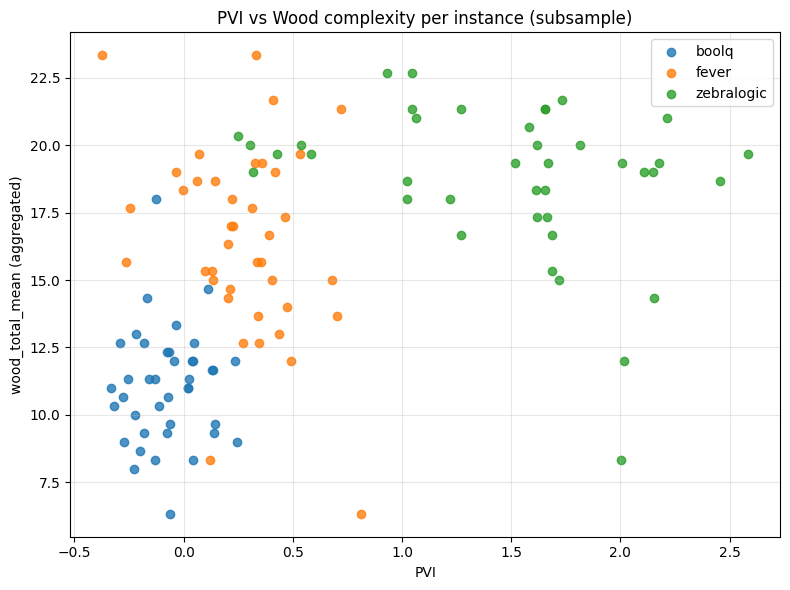

In [61]:
def plot_pvi_vs_wood(df_enriched: pd.DataFrame, y_col: str = "wood_total_mean"):
    # x = PVI (numeric), y = aggregated wood total
    x = pd.to_numeric(df_enriched.get("PVI__numeric", df_enriched.get("PVI")), errors="coerce")
    y = pd.to_numeric(df_enriched[y_col], errors="coerce")

    sub = df_enriched.copy()
    sub["_pvi_x"] = x
    sub["_wood_y"] = y
    sub = sub.dropna(subset=["_pvi_x","_wood_y"])

    # jitter x by dataset to avoid overlap: use dataset on x-axis and show both values as y? 
    # You asked "plot both PVI and wood of each point" — clearest is a 2D scatter.
    plt.figure(figsize=(8,6))
    for ds in sorted(sub["dataset"].unique()):
        s = sub[sub["dataset"] == ds]
        plt.scatter(s["_pvi_x"], s["_wood_y"], alpha=0.8, label=ds)

    
    plt.xlabel("PVI")
    plt.ylabel(f"{y_col} (aggregated)")
    plt.title("PVI vs Wood complexity per instance (subsample)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig('pvi_wood_complexity_per_instance_lr.png', dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

plot_pvi_vs_wood(df_enriched, y_col="wood_total_mean")

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Optional, Dict

def assign_quantile_bins(series: pd.Series, n_bins: int = 6) -> pd.Series:
    return pd.qcut(series, q=n_bins, labels=False, duplicates="drop") + 1

def plot_pvi_vs_wood(
    df_any: pd.DataFrame,
    y_col: str = "wood_total_mean",
    pvi_col_candidates=("PVI__numeric", "PVI"),
    title: str = "PVI vs Wood complexity",
    save_path: str = None,
):
    # x = PVI, y = Wood
    x = None
    for c in pvi_col_candidates:
        if c in df_any.columns:
            x = pd.to_numeric(df_any[c], errors="coerce")
            break
    if x is None:
        raise KeyError(f"None of {pvi_col_candidates} found in df columns.")

    y = pd.to_numeric(df_any[y_col], errors="coerce")

    sub = df_any.copy()
    sub["_pvi_x"] = x
    sub["_wood_y"] = y
    sub = sub.dropna(subset=["_pvi_x", "_wood_y"])

    # compute correlation on what is plotted
    corr = sub["_pvi_x"].corr(sub["_wood_y"])

    plt.figure(figsize=(8,6))
    for ds in sorted(sub["dataset"].unique()):
        s = sub[sub["dataset"] == ds]
        plt.scatter(s["_pvi_x"], s["_wood_y"], alpha=0.85, label=ds)

    plt.xlabel("PVI")
    plt.ylabel(y_col)
    plt.title(f"{title}\nPearson r = {corr:.3f}  (n={len(sub)})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
def subsample_20_by_wood(
    df_enriched: pd.DataFrame,
    wood_col: str = "wood_total_mean",
    n_bins: int = 6,
    n_per_dataset: int = 20,
    bin_allocations: Optional[Dict[str, list]] = None,
    seed: int = 42,
    # NEW:
    make_plot: bool = False,
    plot_title: str = None,
    plot_save_path: str = None,
    plot_y_col: str = None,   # if None, defaults to wood_col
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    out = []

    for ds, g in df_enriched.groupby("dataset"):
        g = g.copy()
        g["_wood"] = pd.to_numeric(g[wood_col], errors="coerce")
        g = g.dropna(subset=["_wood"])
        g["wood_bin"] = assign_quantile_bins(g["_wood"], n_bins).astype(int)

        # default uniform allocation
        if bin_allocations and ds in bin_allocations:
            alloc = np.array(bin_allocations[ds], dtype=int)
        else:
            base = n_per_dataset // n_bins
            rem = n_per_dataset % n_bins
            alloc = np.array([base] * n_bins)
            for i in range(rem):
                alloc[i] += 1

        chosen = []
        for b in range(1, n_bins + 1):
            k = int(alloc[b - 1])
            if k <= 0:
                continue
            bin_df = g[g["wood_bin"] == b]
            if len(bin_df) == 0:
                continue
            pick = rng.choice(bin_df.index, size=min(k, len(bin_df)), replace=False)
            chosen.extend(pick.tolist())

        # top-up if needed
        if len(chosen) < n_per_dataset:
            remaining = g.loc[~g.index.isin(chosen)]
            need = n_per_dataset - len(chosen)
            if len(remaining) > 0:
                extra = rng.choice(remaining.index, size=min(need, len(remaining)), replace=False)
                chosen.extend(extra.tolist())

        out.append(g.loc[chosen].drop(columns=["_wood"]))

    df_sub = pd.concat(out, ignore_index=True)

    # NEW: optional plot hook
    if make_plot:
        y_col = plot_y_col or wood_col
        title = plot_title or f"PVI vs {y_col} (subsample n={n_per_dataset}/dataset)"
        plot_pvi_vs_wood(
            df_sub,
            y_col=y_col,
            title=title,
            save_path=plot_save_path,
        )

    return df_sub


In [28]:
def stratified_sample_by_complexity(
    df: pd.DataFrame,
    wood_col: str = "wood_total_mean",
    n_levels: int = 3,
    n_per_level: int = 300,
    seed: int = 42,
) -> pd.DataFrame:
    """Sample equal number of rows from each complexity level."""
    rng = np.random.default_rng(seed)

    out = df.copy()
    out[wood_col] = pd.to_numeric(out[wood_col], errors="coerce")
    out = out.dropna(subset=[wood_col]).copy()

    # 3 levels of complexity based on quantiles of Wood total score.
    out["complexity_level"] = assign_quantile_bins(out[wood_col], n_levels).astype(int)

    sampled = []
    for lvl in range(1, n_levels + 1):
        g = out[out["complexity_level"] == lvl]
        if len(g) < n_per_level:
            raise ValueError(
                f"Not enough rows in complexity level {lvl}: "
                f"need {n_per_level}, found {len(g)}"
            )
        pick = rng.choice(g.index, size=n_per_level, replace=False)
        sampled.append(out.loc[pick])

    return pd.concat(sampled, ignore_index=True)


# -------- FEVER: 600 questions (200 x 3 levels) --------
N_LEVELS = 3
N_PER_LEVEL_FEVER = 200  # 200 * 3 = 600

df_fever = df_enriched[df_enriched["dataset"].str.lower() == "fever"].copy()
df_fever_600 = stratified_sample_by_complexity(
    df_fever,
    wood_col="wood_total_mean",
    n_levels=N_LEVELS,
    n_per_level=N_PER_LEVEL_FEVER,
    seed=42,
)

OUT_FEVER_600 = f"{OUT_DIR}/fever600_200x3_complexity_{run_name}.csv"
df_fever_600.to_csv(OUT_FEVER_600, index=False)


# Keep old variable name so downstream cells still run.
df_20 = df_fever_600.copy()

print("Saved file:")
print(" -", OUT_FEVER_600, df_fever_600.shape)
print("\nCounts by complexity level (FEVER):")
print(df_fever_600["complexity_level"].value_counts().sort_index())

Saved file:
 - /Users/elena.pervova/Documents/Projects/Bachelor/persuasion-calibration/output_wood/fever600_200x3_complexity_wood_v1_lr_40.csv (600, 39)

Counts by complexity level (FEVER):
complexity_level
1    200
2    200
3    200
Name: count, dtype: int64


In [67]:
sum([5, 4, 3, 2, 1, 0])

15

In [70]:
import numpy as np
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

DATASET_COL = "dataset"

# choose columns to test
PVI_COL = "PVI__numeric" if "PVI__numeric" in df_20.columns else "PVI"
WOOD_COL = "wood_total_mean"
def kruskal_test(df, value_col):
    groups = [
        g[value_col].dropna().values
        for _, g in df.groupby(DATASET_COL)
    ]
    stat, p = kruskal(*groups)
    print(f"\nKruskal–Wallis test for {value_col}")
    print(f"H = {stat:.4f},  p = {p:.6f}")
    return stat, p

kruskal_test(df_20, PVI_COL)
kruskal_test(df_20, WOOD_COL)



Kruskal–Wallis test for PVI__numeric
H = 33.4895,  p = 0.000000

Kruskal–Wallis test for wood_total_mean
H = 39.0293,  p = 0.000000


(39.02928546286517, 3.348870435395519e-09)

In [71]:
def cliffs_delta(x, y):
    # nonparametric effect size
    x = np.array(x)
    y = np.array(y)
    n = 0
    for xi in x:
        n += np.sum(xi > y) - np.sum(xi < y)
    return n / (len(x) * len(y))

def pairwise_tests(df, value_col):
    print(f"\nPairwise Mann–Whitney tests for {value_col}")
    datasets = df[DATASET_COL].unique()

    for d1, d2 in combinations(datasets, 2):
        a = df[df[DATASET_COL] == d1][value_col].dropna()
        b = df[df[DATASET_COL] == d2][value_col].dropna()

        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        delta = cliffs_delta(a, b)

        print(f"{d1} vs {d2}:  U={stat:.2f},  p={p:.6f},  Cliff's delta={delta:.3f}")

pairwise_tests(df_20, PVI_COL)
pairwise_tests(df_20, WOOD_COL)


Pairwise Mann–Whitney tests for PVI__numeric
boolq vs fever:  U=27.00,  p=0.000422,  Cliff's delta=-0.760
boolq vs zebralogic:  U=0.00,  p=0.000003,  Cliff's delta=-1.000
fever vs zebralogic:  U=8.00,  p=0.000016,  Cliff's delta=-0.929

Pairwise Mann–Whitney tests for wood_total_mean
boolq vs fever:  U=0.00,  p=0.000003,  Cliff's delta=-1.000
boolq vs zebralogic:  U=0.00,  p=0.000003,  Cliff's delta=-1.000
fever vs zebralogic:  U=1.00,  p=0.000004,  Cliff's delta=-0.991


In [72]:
def summarize(df, col):
    print(f"\nSummary for {col}")
    print(
        df.groupby(DATASET_COL)[col]
        .agg(["mean","median","std","min","max","count"])
        .round(3)
    )

summarize(df_20, PVI_COL)
summarize(df_20, WOOD_COL)


Summary for PVI__numeric
             mean  median    std    min    max  count
dataset                                              
boolq      -0.020  -0.060  0.160 -0.279  0.244     15
fever       0.233   0.224  0.172 -0.244  0.466     15
zebralogic  1.183   1.064  0.575  0.250  2.212     15

Summary for wood_total_mean
              mean  median    std     min     max  count
dataset                                                 
boolq        9.556   9.333  1.424   6.333  11.667     15
fever       17.133  17.000  1.452  14.667  19.333     15
zebralogic  20.822  21.000  1.015  19.333  22.667     15


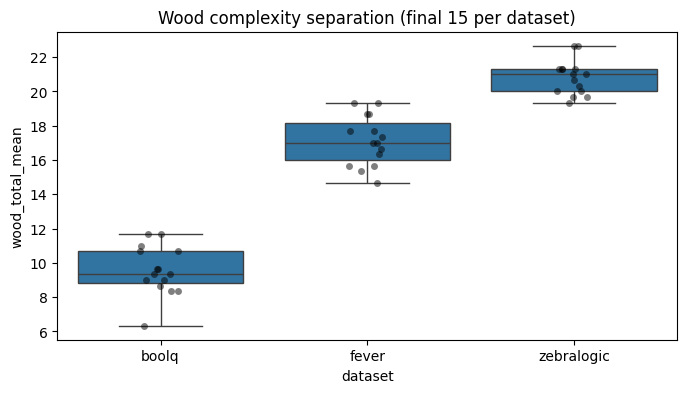

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(data=df_20, x="dataset", y=WOOD_COL)
sns.stripplot(data=df_20, x="dataset", y=WOOD_COL, color="black", alpha=0.5)
plt.title("Wood complexity separation (final 15 per dataset)")
plt.show()